## Домашнее задание
Как узнать свою аудиторию? Построение различных вариантов кластеризаций и интерпретация результатов.

### Цель:
На этот раз займемся классической задачкой - сегментация клиентов (в данном случае - банка). Крайне полезная операция, которая позволяет вам лучше познакомиться со своей аудиторией, понять, на какие группы она делится и чем они характеризуются.

#### Описание/Пошаговая инструкция выполнения домашнего задания:
##### Часть 1. EDA и Preprocessing

1. Скачайте данные по клиентам немецкого банка: https://www.kaggle.com/uciml/german-credit;
2. Проведите EDA, чтобы познакомиться с признаками;
3. Преобразуйте все признаки в числовые подходящими методами;
4. Приведите все данные к одному масштабу (а заодно поясните, почему это необходимая операция при кластеризации).

##### Часть 2. Моделирование

1. Постройте три варианта кластеризации: k-means, hierarhical и DBSCAN, подберите оптимальное количество кластеров для каждого метода при помощи Elbow method и Silhouette plot;
2. Также воспользуйтесь различными вариантами сжатия признакового пространства (PCA, UMAP, tSNE) и визуализируйте результаты кластеризации на двумерной плоскости.

##### Часть 3. Интерпретация

1. Теперь ваша задача - попытаться проинтерпретировать получившиеся кластеры, начните с простого расчета средних значений признаков для каждого из кластеров, есть ли интересные закономерности?
2. Теперь постройте boxplot-ы для каждого признака, сгруппировав значения по кластерам, по каким признакам заметно наибольшее отличие кластеров друг от друга? Можно ли их интерпретировать?

### Критерии оценки:
- EDA и Preprocessing - 2 балла.
- Моделирование - 5 баллов.
- Интерпретация - 3 балла.

## Решение

### Описание датасета

#### Context
The original dataset contains 1000 entries with 20 categorial/symbolic attributes prepared by Prof. Hofmann. In this dataset, each entry represents a person who takes a credit by a bank. Each person is classified as good or bad credit risks according to the set of attributes. 

#### Content
It is almost impossible to understand the original dataset due to its complicated system of categories and symbols. Thus, I wrote a small Python script to convert it into a readable CSV file. Several columns are simply ignored, because in my opinion either they are not important or their descriptions are obscure. The selected attributes are:

- Age (numeric)
- Sex (text: male, female)
- Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)
- Housing (text: own, rent, or free)
- Saving accounts (text - little, moderate, quite rich, rich)
- Checking account (numeric, in DM - Deutsch Mark)
- Credit amount (numeric, in DM)
- Duration (numeric, in month)
- Purpose (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)

### 1. EDA и Preprocessing

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

1. На EDA посмотреть на данные в сниженной размерности, чтобы оценить характер их распределения
2. Числовые данные необходимо масштабировать так как в моделях считается расстояние между наблюдениями
3. При кластеризации следует стремиться, чтобы наименьший кластер содержал более 5% данных

In [8]:
df = pd.read_csv('./german_credit_data.csv', sep=',')

In [9]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [10]:
# Пропуски в столбцах Saving accounts и Checking account
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [11]:
# В предположение, что признаки Saving accounts и Checking account обозначают совокупный размер сберегательных счетов и размер текущего счета,
# для пустых значений в этих столбцах ввожу новую категорию 'empty'
df[['Saving accounts','Checking account']] = df[['Saving accounts','Checking account']].fillna('empty')

In [17]:
# Удаляю первый столбец так как он похож на порядковый номер строки и потому ценности не представляет
drop_features = ['Unnamed: 0']

binary_features = [
    'Sex',
]

ordered_features = [
    'Housing',
    'Saving accounts',
    'Checking account'
]

category_features = [
    'Purpose',
]

In [14]:
clean_df = df.drop(labels=drop_features, axis=1)

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [18]:
for feature in ordered_features + category_features + binary_features:
    print(f'{feature}: \n\t{clean_df[feature].unique()}')

Housing: 
	['own' 'free' 'rent']
Saving accounts: 
	['empty' 'little' 'quite rich' 'rich' 'moderate']
Checking account: 
	['little' 'moderate' 'empty' 'rich']
Purpose: 
	['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']
Sex: 
	['male' 'female']


In [19]:
# Преобразование нечисловых признаков
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

def get_encoded_feature_name(feature, category):
    return str(feature) + "_" + str(category)


ordinal_encoder = OrdinalEncoder(categories=[
        ['rent', 'free', 'own'],
        ['empty', 'little', 'moderate',  'quite rich', 'rich'],
        ['empty', 'little', 'moderate',  'quite rich', 'rich'],
    ],
    dtype=np.int16
)

binary_encoder = OneHotEncoder(
    sparse_output=False, 
    drop='if_binary', 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)

category_encoder = OneHotEncoder(
    sparse_output=False, 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)

encoded_df = clean_df.copy()
encoded_df[binary_encoder.get_feature_names_out()] = binary_encoder.fit_transform(encoded_df[binary_features])
encoded_df[ordered_features] = ordinal_encoder.fit_transform(encoded_df[ordered_features])
encoded_df[category_encoder.get_feature_names_out()] = category_encoder.fit_transform(encoded_df[category_features])

encoded_df = encoded_df.drop(binary_features + category_features, axis=1)
encoded_df.head()

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,2,0,1,1169,6,1,0,0,0,0,0,1,0,0
1,22,2,2,1,2,5951,48,0,0,0,0,0,0,1,0,0
2,49,1,2,1,0,2096,12,1,0,0,0,1,0,0,0,0
3,45,2,1,1,1,7882,42,1,0,0,0,0,1,0,0,0
4,53,2,1,1,1,4870,24,1,0,1,0,0,0,0,0,0


In [21]:
encoded_df.describe()

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,35.546000,1.904000,1.534000,1.190000,1.06400,3271.258000,20.903000,0.690000,0.097000,0.337000,0.01200,0.059000,0.181000,0.280000,0.022000,0.01200
std,11.375469,0.653614,0.779392,0.966869,1.10776,2822.736876,12.058814,0.462725,0.296106,0.472921,0.10894,0.235743,0.385211,0.449224,0.146757,0.10894
min,19.000000,0.000000,0.000000,0.000000,0.00000,250.000000,4.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,27.000000,2.000000,1.000000,1.000000,0.00000,1365.500000,12.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,33.000000,2.000000,2.000000,1.000000,1.00000,2319.500000,18.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,42.000000,2.000000,2.000000,1.000000,2.00000,3972.250000,24.000000,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.00000
max,75.000000,3.000000,2.000000,4.000000,4.00000,18424.000000,72.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000


In [24]:
synthetic_category_feature = [column for column in encoded_df.columns for category_feature in category_features if category_feature in column]
synthetic_category_feature

['Purpose_business',
 'Purpose_car',
 'Purpose_domestic appliances',
 'Purpose_education',
 'Purpose_furniture/equipment',
 'Purpose_radio/TV',
 'Purpose_repairs',
 'Purpose_vacation/others']

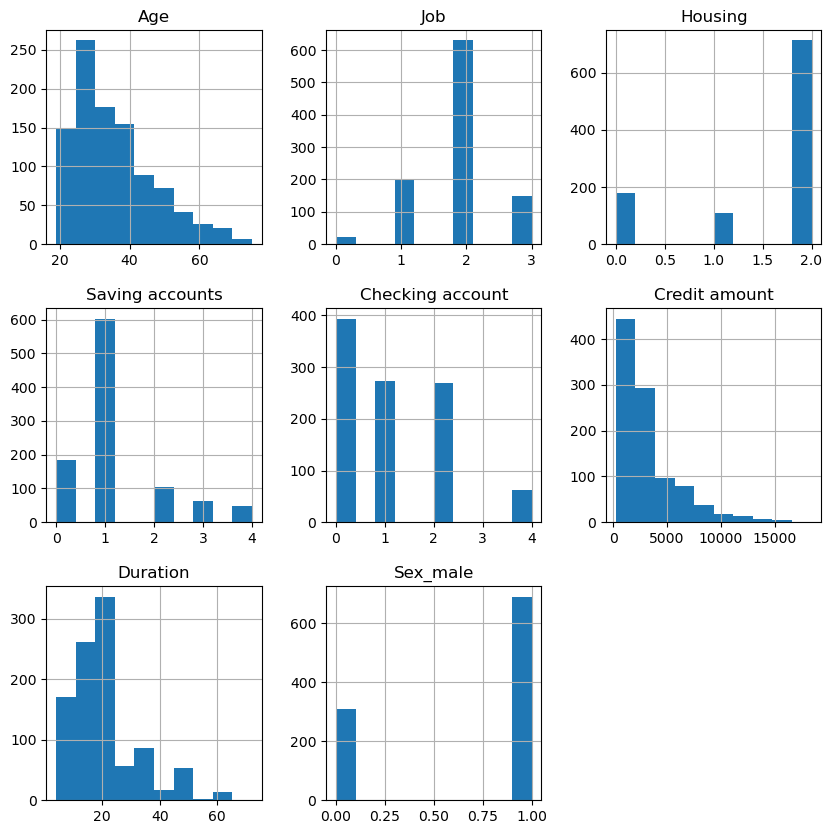

In [29]:
# Гистограммы распределения всех числовых значений за исключением категориальных признаков
synthetic_category_feature = [column for column in encoded_df.columns for category_feature in category_features if category_feature in column]

encoded_df.drop(synthetic_category_feature, axis=1).hist(figsize=(10,10));

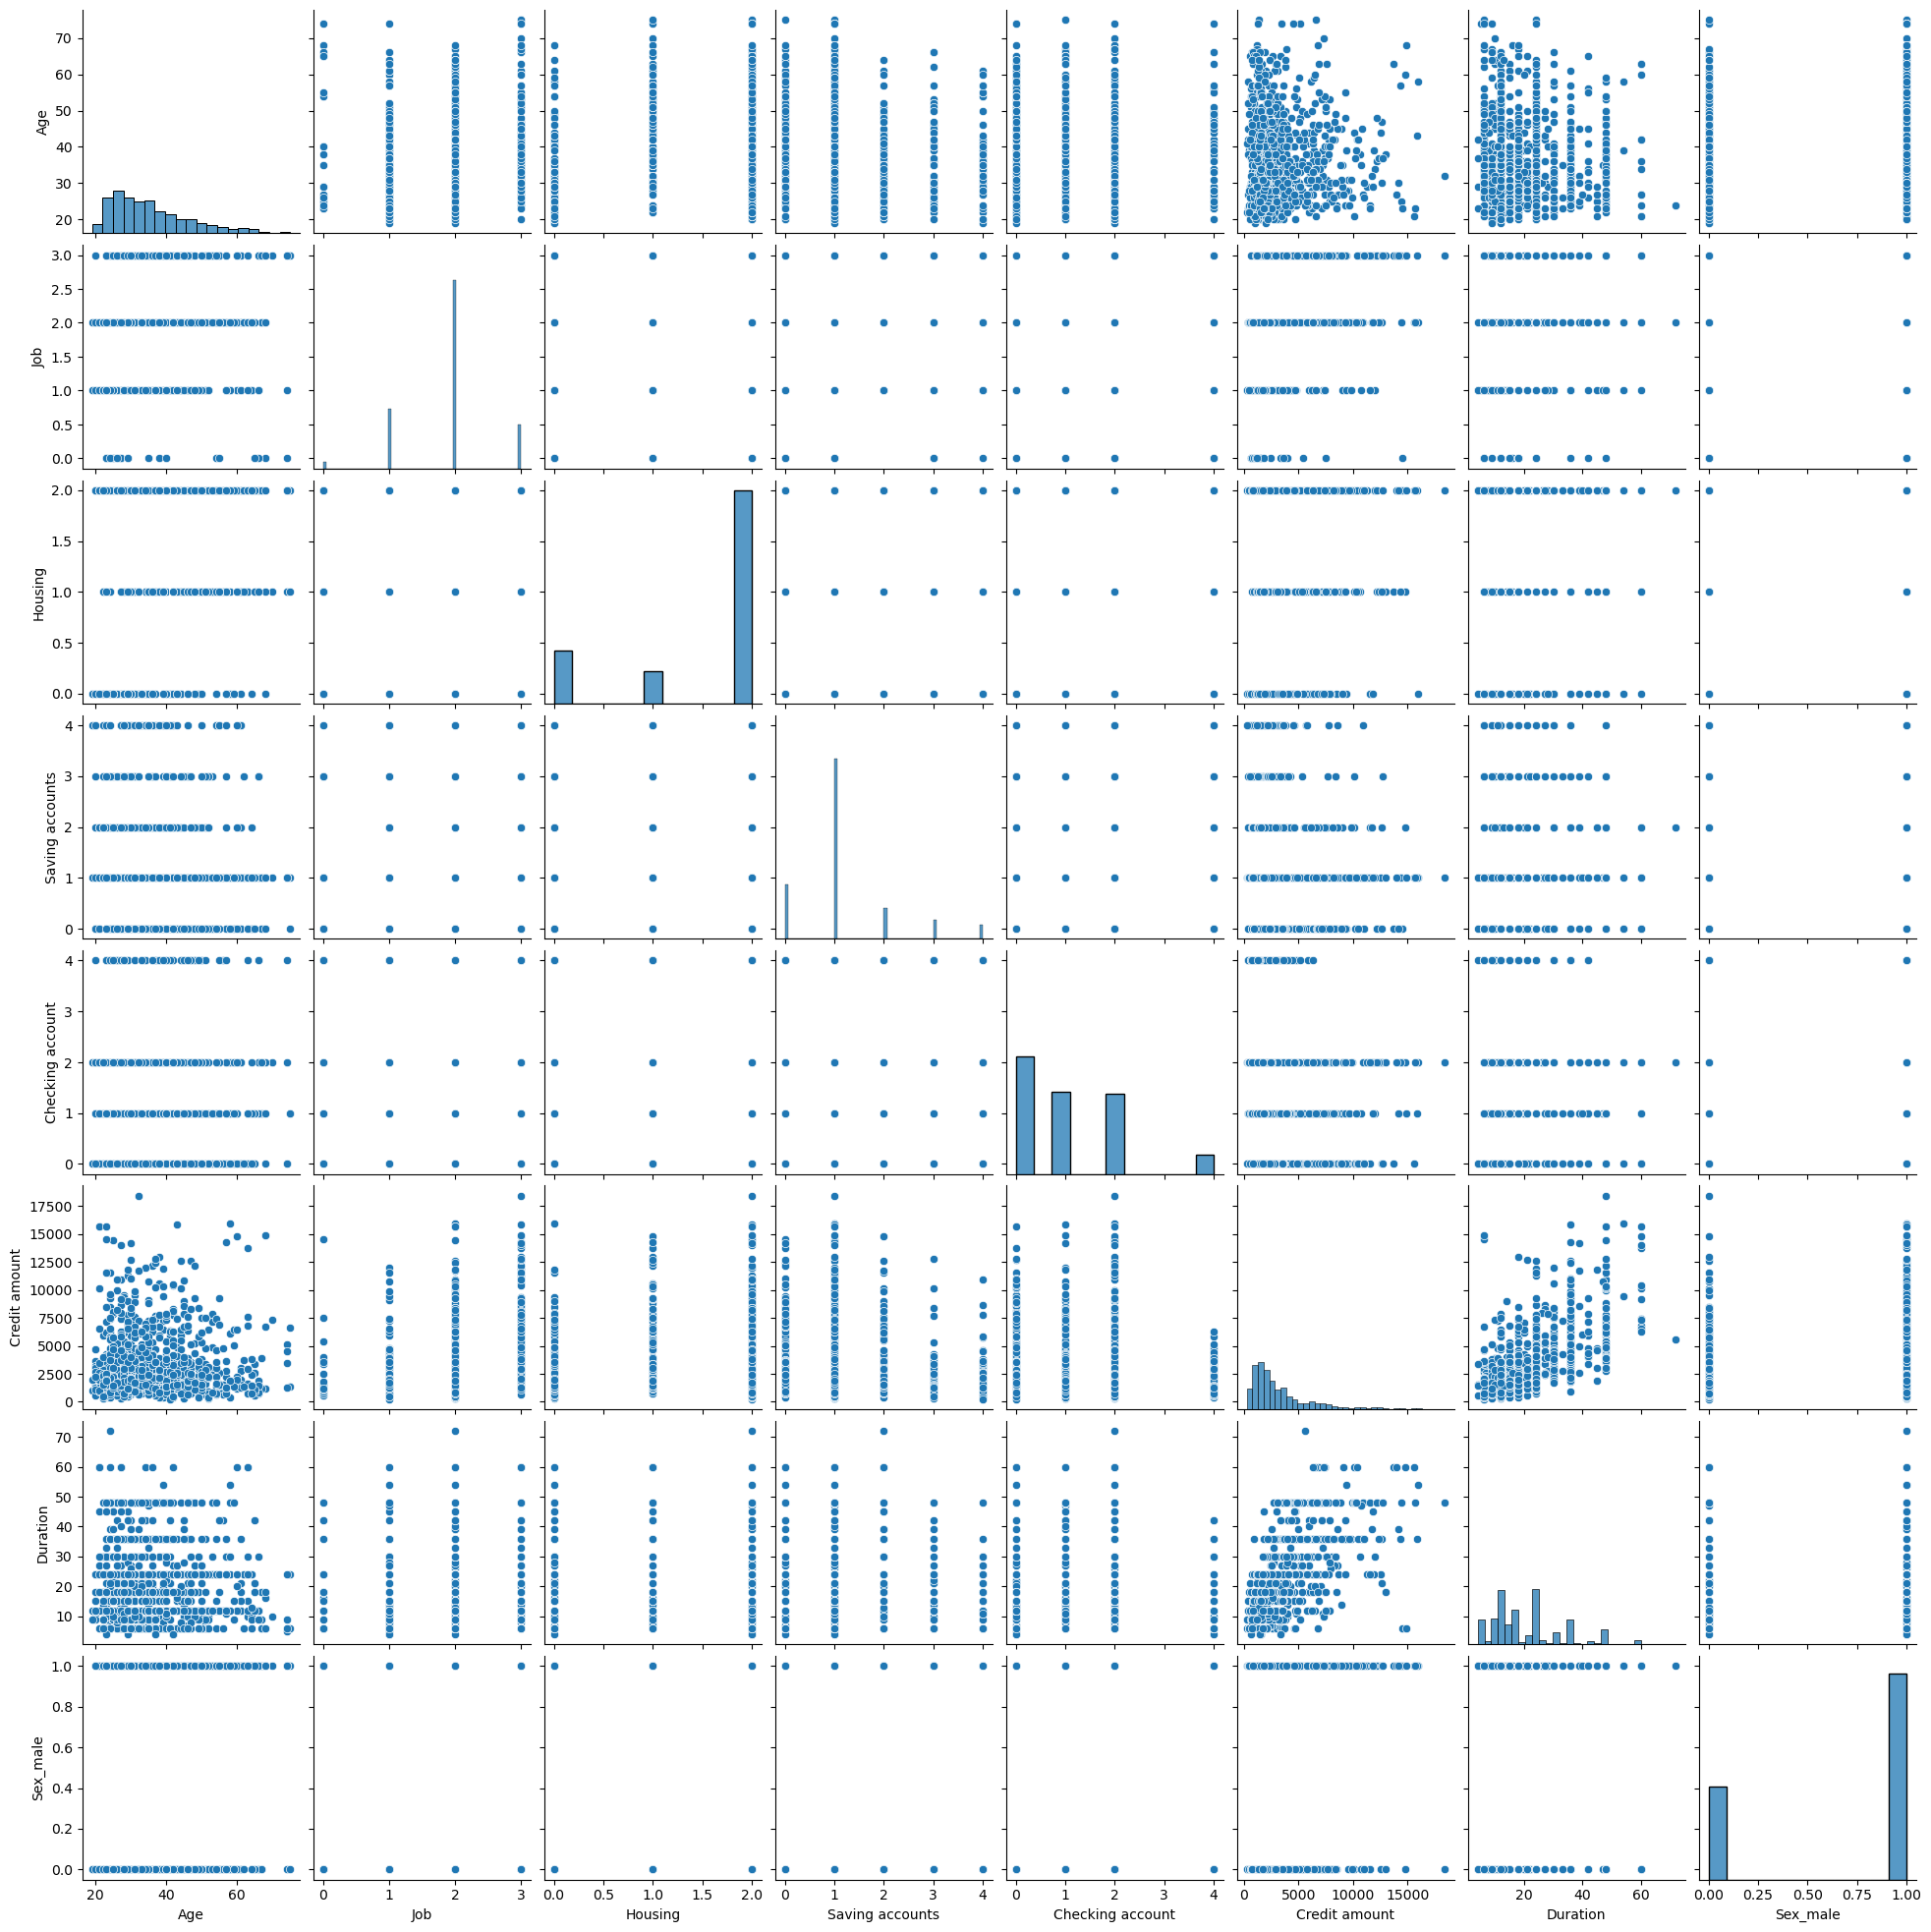

In [32]:
sns.pairplot(encoded_df.drop(synthetic_category_feature, axis=1));

<Axes: >

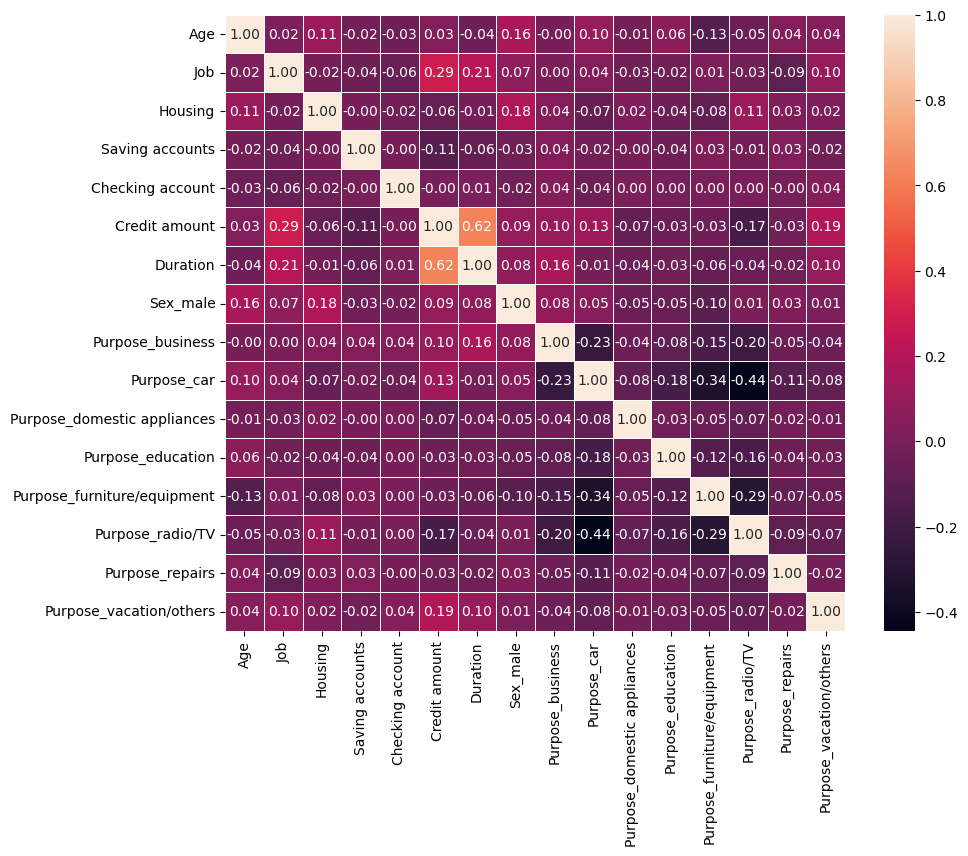

In [28]:
# Корреляция
plt.figure(figsize=(10, 8))
sns.heatmap(encoded_df.corr(), annot=True, cbar=True, linewidths=.5, fmt= '.2f')

#### Нормализация

Числовые данные необходимо нормализовать, так как в моделях считается расстояние между наблюдениями и для этого важен единый масштаб.

In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(encoded_df)
scaled_df = pd.DataFrame(scaler.transform(encoded_df), columns=encoded_df.columns)

scaled_df.describe()

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.295464,0.634667,0.767000,0.297500,0.26600,0.166241,0.248574,0.690000,0.097000,0.337000,0.01200,0.059000,0.181000,0.280000,0.022000,0.01200
std,0.203133,0.217871,0.389696,0.241717,0.27694,0.155317,0.177336,0.462725,0.296106,0.472921,0.10894,0.235743,0.385211,0.449224,0.146757,0.10894
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.142857,0.666667,0.500000,0.250000,0.00000,0.061379,0.117647,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,0.250000,0.666667,1.000000,0.250000,0.25000,0.113871,0.205882,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,0.410714,0.666667,1.000000,0.250000,0.50000,0.204812,0.294118,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.00000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000


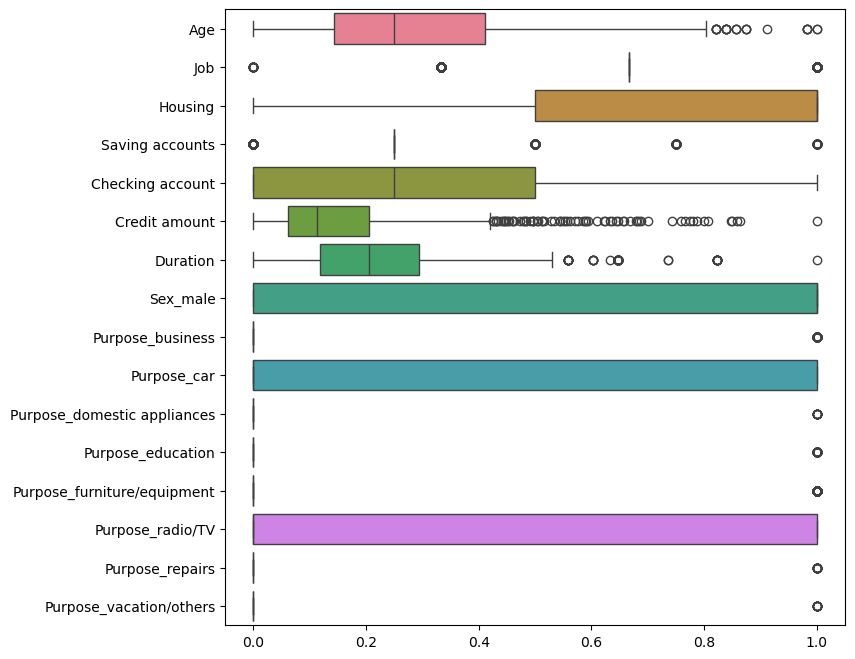

In [70]:
plt.figure(figsize=(8,8))
sns.boxplot(data=scaled_df, orient='h');

#### Визуализация данных в сниженной размерности

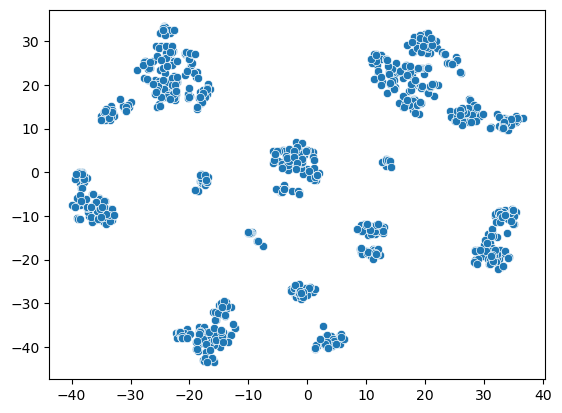

In [71]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=10)
X_tsne = tsne.fit_transform(scaled_df)

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1]);